### Remove bad data

In [77]:
# from pathlib import Path

# BASE = Path("/data/ahmed/MIMIC_Dataset/mimic-iv-ecg/files")
# clean_list_path = Path("clean_record_paths.txt")

# clean_record_paths = []

# for hea in hea_files:
#     rp = str(hea.with_suffix(""))
#     dat = Path(rp + ".dat")

#     # must exist
#     if not dat.exists():
#         continue

#     # must be non-empty
#     if hea.stat().st_size == 0:
#         continue
#     if dat.stat().st_size == 0:
#         continue

#     # reject duplicated header files
#     txt = hea.read_text(errors="replace")
#     lines = [x.rstrip("\n\r") for x in txt.splitlines() if x.strip() != ""]

#     if len(lines) % 2 == 0:
#         half = len(lines) // 2
#         if lines[:half] == lines[half:]:
#             continue

#     clean_record_paths.append(rp)

# clean_list_path.write_text("\n".join(clean_record_paths))

# print(f"Clean usable record paths : {len(clean_record_paths):,}")
# print(f"Saved to                  : {clean_list_path.resolve()}")

### Precompute

In [3]:
from pathlib import Path
import hashlib
import json
import numpy as np
import wfdb
from tqdm.auto import tqdm

# -------------------------
# paths
# -------------------------
clean_list_path = Path("clean_record_paths.txt")
cache_dir = Path("/data/ahmed/MIMIC_Dataset/mimic_precomputed_npys")
cache_dir.mkdir(parents=True, exist_ok=True)

record_paths = clean_list_path.read_text().splitlines()
print(f"Loaded {len(record_paths):,} candidate record paths")

# -------------------------
# same preprocessing logic
# -------------------------
CLIP_VALUE = 5.0
MAX_MISSING_FRAC = 0.05

def sanitize(x, max_missing_frac=0.05):
    x = np.where(np.isinf(x), np.nan, x)

    if np.isnan(x).mean() > max_missing_frac:
        return None

    lead_missing_frac = np.isnan(x).mean(axis=1)
    if (lead_missing_frac > max_missing_frac).any():
        return None

    if np.isnan(x).all(axis=1).any():
        return None

    for c in range(x.shape[0]):
        lead = x[c]
        if np.isnan(lead).any():
            idx = np.arange(len(lead))
            mask = np.isfinite(lead)
            if mask.sum() < 2:
                return None
            x[c] = np.interp(idx, idx[mask], lead[mask])

    if not np.isfinite(x).all():
        return None

    return x

def zscore_per_lead(x, clip_value=5.0):

    x = np.clip(x, -clip_value, clip_value)
    
    mean = x.mean(axis=1, keepdims=True)
    std = x.std(axis=1, keepdims=True)

    x = (x - mean) / np.clip(std, 1e-4, None)
    

    if not np.isfinite(x).all():
        return None

    return x.astype(np.float32, copy=False)

def record_to_cache_name(rp: str) -> str:
    # stable filename, avoids weird path issues
    h = hashlib.md5(rp.encode("utf-8")).hexdigest()
    return f"{h}.npy"

# -------------------------
# preprocess once
# -------------------------
saved = 0
skipped = 0
manifest = []

for rp in tqdm(record_paths):
    out_name = record_to_cache_name(rp)
    out_path = cache_dir / out_name

    if out_path.exists():
        manifest.append({"record_path": rp, "npy_path": str(out_path)})
        saved += 1
        continue

    rec = wfdb.rdrecord(rp)
    x = rec.p_signal.astype(np.float32).T   # (12, 5000)

    if x.shape != (12, 5000):
        skipped += 1
        continue

    x = sanitize(x, max_missing_frac=MAX_MISSING_FRAC)
    if x is None:
        skipped += 1
        continue

    x = zscore_per_lead(x, clip_value=CLIP_VALUE)
    if x is None:
        skipped += 1
        continue

    np.save(out_path, x)
    manifest.append({"record_path": rp, "npy_path": str(out_path)})
    saved += 1

manifest_path = cache_dir / "manifest.jsonl"
with manifest_path.open("w") as f:
    for row in manifest:
        f.write(json.dumps(row) + "\n")

print(f"Saved precomputed arrays : {saved:,}")
print(f"Skipped during preprocess: {skipped:,}")
print(f"Manifest                 : {manifest_path}")
print(f"Cache dir                : {cache_dir}")

Loaded 774,629 candidate record paths


  0%|          | 0/774629 [00:00<?, ?it/s]

Saved precomputed arrays : 772,591
Skipped during preprocess: 2,038
Manifest                 : /data/ahmed/MIMIC_Dataset/mimic_precomputed_npys/manifest.jsonl
Cache dir                : /data/ahmed/MIMIC_Dataset/mimic_precomputed_npys


### MIMIC-IV-ECG Data Health & Preprocessing Summary

**Total Records Analyzed:** 774,629

#### 1. Missing Data (NaNs & Infs)
* **Perfectly Clean:** 95.42% (739,167 files)
* **Contains Missing Data:** 4.58% (35,462 files)

#### 2. Severity of Missing Data (Inside the 4.58%)
For the records that contained missing values, the corruption was overwhelmingly minor:
* **Median Missing Data:** 0.01% per file (~6 samples or 12 milliseconds)
* **Average Missing Data:** 0.17% per file
* **Worst File:** 67.98% missing data

**Breakdown & Action Taken:**
* **Minor Corruption (< 5% missing):** 35,328 files. 
  * *Action:* Retained. Applied fast 1D linear interpolation to smoothly bridge the micro-gaps without introducing artificial high-frequency artifacts (step-edges).
* **Major Corruption (> 5% missing):** 134 files. 
  * *Action:* Dropped entirely from the dataloader to prevent the model from learning massive, artificial straight lines.

#### 3. Flat Leads (Zero Variance)
Records where at least one lead had identical max and min voltages (a perfectly flat line):
* **Healthy / Dynamic Files:** 99.80% (773,059 files)
* **Contains $\ge 1$ Flat Lead:** 0.20% (1,570 files)

**Action Taken:** * *Retained.* During Z-normalization, the standard deviation is safely clipped at `1e-4` (`np.clip(std, 1e-4, None)`). This elegantly evaluates flat leads to arrays of exactly `0.0`s instead of throwing fatal `NaN` zero-division errors during training. 

#### 4. Sanitize
Sanitize will fail for 2,038 (0.26%) files.

#### Conclusion
The dataset is extremely healthy. By dropping only 134 highly corrupted files and interpolating the micro-blips in the remaining 4.5%, the Masked Autoencoder receives highly continuous, artifact-free physiological data without losing statistically significant sample size.

In [ ]:
from pathlib import Path
import random
import time
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import wfdb

# -------------------------
# Reproducibility / device
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')
print("Device:", device)

# -------------------------
# Paths / config
# -------------------------
BASE = Path("/data/ahmed/MIMIC_Dataset/mimic-iv-ecg/files")
assert BASE.exists(), f"Base path does not exist: {BASE}"

# data / model
PATCH_SIZE = 50              
SEQ_LEN = 5000 // PATCH_SIZE     
IN_CHANNELS = 12
PATCH_DIM = IN_CHANNELS * PATCH_SIZE   # 6000
D_MODEL = 256
NUM_HEADS = 8
NUM_LAYERS = 4
MLP_RATIO = 4
DROPOUT = 0.1

# masking
MASK_RATIO = 0.50
MASK_SPAN_LEN = 1   # 1 token = 1000 ms

# training
MAX_RECORDS = None      # None = full dataset
TRAIN_FRAC = 0.95
BATCH_SIZE = 256
NUM_WORKERS = 12 
PREFETCH_FACTOR = 4
PIN_MEMORY = True
PERSISTENT_WORKERS = True 

EPOCHS = 20
LR = 2e-5
WEIGHT_DECAY = 0.05
LOG_EVERY = 50
PLOT_EVERY = 500
MAX_RETRIES = 50

# -------------------------
# Dataset
# -------------------------
class MIMICECGDataset(Dataset):
    def __init__(self, record_paths, clip_value=5.0):
        self.record_paths = record_paths
        self.clip_value = clip_value

    def __len__(self):
        return len(self.record_paths)

    def _sanitize(self, x, max_missing_frac=0.05):
        x = np.where(np.isinf(x), np.nan, x)

        # reject if too much missing overall
        if np.isnan(x).mean() > max_missing_frac:
            return None

        # reject if any lead is too damaged
        lead_missing_frac = np.isnan(x).mean(axis=1)
        if (lead_missing_frac > max_missing_frac).any():
            return None

        # reject dead leads
        if np.isnan(x).all(axis=1).any():
            return None

        # interpolate minor gaps
        for c in range(x.shape[0]):
            lead = x[c]
            if np.isnan(lead).any():
                idx = np.arange(len(lead))
                mask = np.isfinite(lead)

                if mask.sum() < 2:
                    return None

                x[c] = np.interp(idx, idx[mask], lead[mask])

        if not np.isfinite(x).all():
            return None

        return x

    def _zscore_per_lead(self, x):

        x = np.clip(x, -self.clip_value, self.clip_value)

        mean = x.mean(axis=1, keepdims=True)
        std = x.std(axis=1, keepdims=True)

        x = (x - mean) / np.clip(std, 1e-4, None)

        if not np.isfinite(x).all():
            return None

        return x

    def __getitem__(self, idx):
        try:
            rp = self.record_paths[idx]
            rec = wfdb.rdrecord(rp)
            x = rec.p_signal.astype(np.float32).T   # (12, 5000)

            if x.shape != (12, 5000):
                raise ValueError(f"Bad shape for {rp}: {x.shape}")

            x = self._sanitize(x)
            if x is None:
                raise ValueError(f"Sanitize failed for {rp}")

            x = self._zscore_per_lead(x)
            if x is None:
                raise ValueError(f"Z-score failed for {rp}")

            return {
                "x": torch.from_numpy(x),
                "record_path": rp,
            }
        except Exception as e:
            # print(f"Error loading record {self.record_paths[idx]}: {e}")
            import random
            new_idx = random.randint(0, len(self.record_paths) - 1)
            return self.__getitem__(new_idx)

class PrecomputedECGDataset(Dataset):
    def __init__(self, npy_paths):
        self.npy_paths = npy_paths

    def __len__(self):
        return len(self.npy_paths)

    def __getitem__(self, idx):
        npy_path = self.npy_paths[idx]
        x = np.load(npy_path, mmap_mode=None)   # shape (12, 5000), float32

        if x.shape != (12, 5000):
            raise ValueError(f"Bad cached shape for {npy_path}: {x.shape}")

        return {
            "x": torch.from_numpy(x),
            "record_path": npy_path,
        }

# -------------------------
# Positional encoding
# -------------------------
class LearnablePositionalEncoding(nn.Module):
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.pos = nn.Parameter(torch.zeros(1, seq_len, d_model))
        nn.init.trunc_normal_(self.pos, std=0.02)

    def forward(self, x):
        return x + self.pos.to(dtype=x.dtype, device=x.device)

class SinCosPositionalEncoding(nn.Module):
    def __init__(self, seq_len, d_model):
        super().__init__()
        assert d_model % 2 == 0, "d_model must be even for sin-cos positional encoding"

        position = torch.arange(seq_len, dtype=torch.float32).unsqueeze(1)   # (N, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) *
            (-math.log(10000.0) / d_model)
        )  # (D/2,)

        pe = torch.zeros(1, seq_len, d_model, dtype=torch.float32)           # (1, N, D)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe, persistent=False)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(dtype=x.dtype, device=x.device)

# -------------------------
# Tokenizer
# -------------------------
class FixedCNNTokenizer(nn.Module):
    def __init__(self, in_channels=12, d_model=256, patch_size=50):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv1d(
            in_channels=in_channels,
            out_channels=d_model,
            kernel_size=patch_size,
            stride=patch_size,
            bias=True,
        )

    def forward(self, x):
        # x: (B, 12, 5000)
        z = self.proj(x)          # (B, D, N)
        z = z.transpose(1, 2)     # (B, N, D)
        return z

# -------------------------
# Transformer
# -------------------------
class TransformerEncoder(nn.Module):
    def __init__(self, d_model=256, num_heads=8, num_layers=4, mlp_ratio=4, dropout=0.1):
        super().__init__()
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=d_model * mlp_ratio,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

    def forward(self, x):
        return self.encoder(x)

# -------------------------
# Contiguous masking (safe)
# -------------------------
def contiguous_token_mask(batch_size, seq_len, mask_ratio, device, span_len=3, max_tries=1000):
    """
    Returns:
      mask: (B, N) bool, True = masked
    """
    num_mask = int(round(seq_len * mask_ratio))
    mask = torch.zeros(batch_size, seq_len, dtype=torch.bool, device=device)

    for b in range(batch_size):
        tries = 0
        while int(mask[b].sum().item()) < num_mask and tries < max_tries:
            tries += 1

            remaining = num_mask - int(mask[b].sum().item())
            current_span = min(span_len, remaining)

            start_max = max(1, seq_len - current_span + 1)
            start = torch.randint(0, start_max, (1,), device=device).item()
            end = start + current_span

            # skip spans that overlap already masked region
            if mask[b, start:end].any():
                continue

            mask[b, start:end] = True

        # fallback: fill any remaining slots randomly without infinite loop risk
        if int(mask[b].sum().item()) < num_mask:
            unmasked_idx = (~mask[b]).nonzero(as_tuple=False).squeeze(1)
            remaining = num_mask - int(mask[b].sum().item())
            if len(unmasked_idx) > 0:
                pick = unmasked_idx[torch.randperm(len(unmasked_idx), device=device)[:remaining]]
                mask[b, pick] = True

    return mask

# -------------------------
# Model: raw patch reconstruction
# -------------------------
class ECGMaskedSSL(nn.Module):
    def __init__(
        self,
        in_channels=12,
        seq_len=100,
        d_model=256,
        patch_size=50,
        num_heads=8,
        num_layers=4,
        mlp_ratio=4,
        dropout=0.1,
    ):
        super().__init__()
        self.in_channels = in_channels
        self.patch_size = patch_size
        self.patch_dim = in_channels * patch_size

        self.tokenizer = FixedCNNTokenizer(in_channels, d_model, patch_size)
        self.posenc = SinCosPositionalEncoding(seq_len, d_model)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.mask_token, std=0.02)

        self.encoder = TransformerEncoder(
            d_model=d_model,
            num_heads=num_heads,
            num_layers=num_layers,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )

        # reconstruct raw patch values: 12 * 50 = 600 outputs per token
        self.pred_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, self.patch_dim),
        )

    def patchify(self, x):
        """
        x: (B, C, T)
        returns raw patches: (B, N, C*P)
        """
        B, C, T = x.shape
        P = self.patch_size
        assert T % P == 0
        N = T // P
        patches = x.view(B, C, N, P).permute(0, 2, 1, 3).contiguous()   # (B, N, C, P)
        patches = patches.view(B, N, C * P)                              # (B, N, C*P)
        return patches

    def forward(self, x, mask = None, mask_ratio=0.50, span_len=5):
        tokens = self.tokenizer(x)                # (B, N, D)
        B, N, D = tokens.shape

        target_patches = self.patchify(x)         # (B, N, 600)
        if mask is None:
            mask = contiguous_token_mask(B, N, mask_ratio, x.device, span_len=span_len)

        mask_token = self.mask_token.to(dtype=tokens.dtype, device=tokens.device).expand(B, N, D)
        masked_tokens = torch.where(mask.unsqueeze(-1), mask_token, tokens)

        masked_tokens = self.posenc(masked_tokens)
        encoded = self.encoder(masked_tokens)
        pred_patches = self.pred_head(encoded)    # (B, N, 600)
        pooled = encoded.mean(dim=1)

        return {
            "pred_patches": pred_patches,
            "target_patches": target_patches,
            "mask": mask,
            "encoded": encoded,
            "pooled": pooled,
        }

def masked_patch_mse_loss(pred_patches, target_patches, mask, norm_target=False):
    pred_patches = pred_patches.float()
    target_patches = target_patches.float()

    if norm_target:
        mean = target_patches.mean(dim=-1, keepdim=True)
        std = target_patches.std(dim=-1, keepdim=True).clamp(min=1e-6)

        target_patches = (target_patches - mean) / std
        pred_patches = (pred_patches - mean) / std

    mask_expanded = mask.unsqueeze(-1).expand_as(pred_patches)
    diff2 = (pred_patches - target_patches) ** 2
    return diff2[mask_expanded].mean()

Device: cuda:1


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import clear_output

CHECKPOINT_DIR = Path("./checkpoints_fixed500_ssl")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Build record list
# -------------------------

from pathlib import Path
import json

cache_dir = Path("/data/ahmed/MIMIC_Dataset/mimic_precomputed_npys")
manifest_path = cache_dir / "manifest.jsonl"

rows = [json.loads(line) for line in manifest_path.read_text().splitlines()]
npy_paths = [row["npy_path"] for row in rows]

print(f"Precomputed arrays loaded: {len(npy_paths):,}")

if MAX_RECORDS is not None:
    npy_paths = npy_paths[:MAX_RECORDS]
    print(f"Using first {len(npy_paths):,} cached records")
else:
    print(f"Using all {len(npy_paths):,} cached records")

dataset = PrecomputedECGDataset(npy_paths)

n_total = len(dataset)
n_train = int(TRAIN_FRAC * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Train size: {len(train_dataset):,}")
print(f"Val size  : {len(val_dataset):,}")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=PREFETCH_FACTOR,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=PREFETCH_FACTOR,
)

# -------------------------
# Model / optimizer
# -------------------------
model = ECGMaskedSSL(
    in_channels=IN_CHANNELS,
    seq_len=SEQ_LEN,
    d_model=D_MODEL,
    patch_size=PATCH_SIZE,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
).to(device)

model = torch.compile(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

# -------------------------
# Warmup + cosine decay
# -------------------------
total_steps = EPOCHS * len(train_loader)
warmup_steps = int(0.05 * total_steps)  # 5% warmup

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step + 1) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"Total train steps : {total_steps:,}")
print(f"Warmup steps      : {warmup_steps:,}")

Precomputed arrays loaded: 772,591
Using all 772,591 cached records
Train size: 733,961
Val size  : 38,630


/tmp/ipykernel_431466/3628415255.py:233: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Total train steps : 57,340
Warmup steps      : 2,867


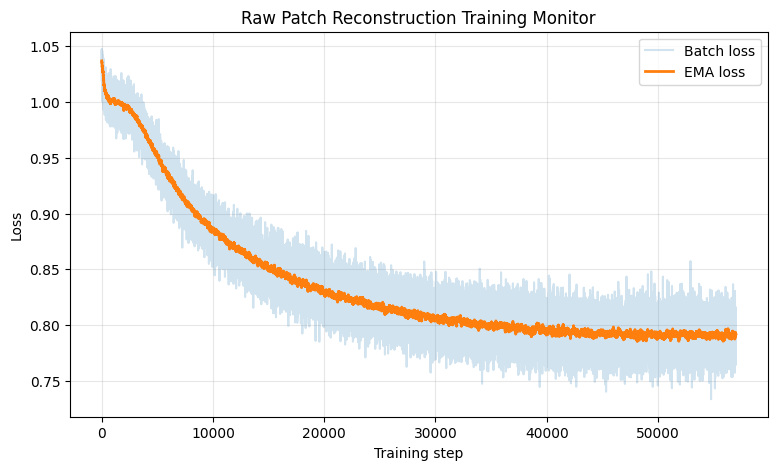

  step  2550/ 2867 | batch_loss 0.7696 | avg_loss 0.7911 | lr 1.67e-09 | 596.4s
  step  2600/ 2867 | batch_loss 0.7971 | avg_loss 0.7910 | lr 1.19e-09 | 607.1s
  step  2650/ 2867 | batch_loss 0.7715 | avg_loss 0.7910 | lr 7.83e-10 | 621.7s
  step  2700/ 2867 | batch_loss 0.7864 | avg_loss 0.7909 | lr 4.64e-10 | 632.3s
  step  2750/ 2867 | batch_loss 0.8048 | avg_loss 0.7909 | lr 2.28e-10 | 642.9s
  step  2800/ 2867 | batch_loss 0.7896 | avg_loss 0.7910 | lr 7.47e-11 | 656.6s
  step  2850/ 2867 | batch_loss 0.7607 | avg_loss 0.7910 | lr 4.81e-12 | 667.7s
Epoch 20 | train_loss=0.7910 | val_loss=0.7675
  Saved new best checkpoint to: checkpoints_fixed500_ssl/best.pt

Done training.
Best val loss: 0.7675151039433006
Checkpoint dir: checkpoints_fixed500_ssl


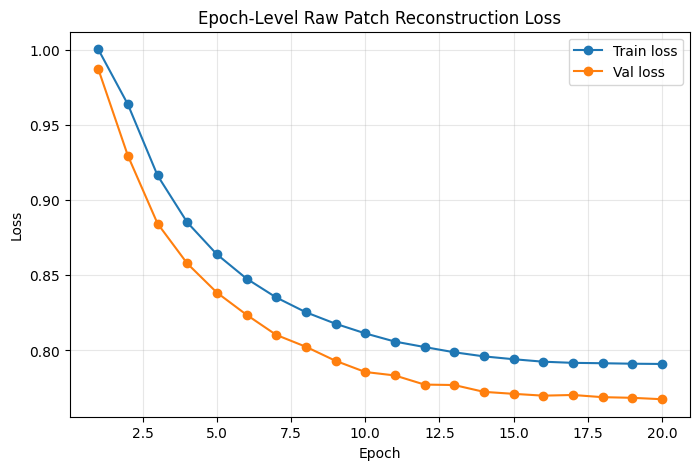

In [3]:
def run_epoch(
    model,
    loader,
    optimizer=None,
    scheduler=None,
    train=True,
    global_step=0,
    plot_every=500,
    step_history=None,
    ema_alpha=0.03,
):
    model.train(train)

    running_loss = 0.0
    n_batches = 0
    start_time = time.time()

    grad_context = torch.enable_grad() if train else torch.no_grad()

    with grad_context:
        for step, batch in enumerate(loader, start=1):
            x = batch["x"].to(device, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)

            mask = contiguous_token_mask(x.shape[0], SEQ_LEN, MASK_RATIO, device, span_len=MASK_SPAN_LEN)
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                out = model(x, mask=mask)
                loss = masked_patch_mse_loss(out["pred_patches"], out["target_patches"], out["mask"], norm_target=False)

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()

                global_step += 1
                batch_loss = loss.item()

                if step_history is not None:
                    step_history["step"].append(global_step)
                    step_history["batch_loss"].append(batch_loss)

                    if len(step_history["ema_loss"]) == 0:
                        ema = batch_loss
                    else:
                        ema = ema_alpha * batch_loss + (1 - ema_alpha) * step_history["ema_loss"][-1]
                    step_history["ema_loss"].append(ema)

                if step_history is not None and global_step % plot_every == 0:
                    clear_output(wait=True)

                    plt.figure(figsize=(9, 5))
                    plt.plot(step_history["step"], step_history["batch_loss"], alpha=0.20, label="Batch loss")
                    plt.plot(step_history["step"], step_history["ema_loss"], linewidth=2, label="EMA loss")
                    plt.xlabel("Training step")
                    plt.ylabel("Loss")
                    plt.title("Raw Patch Reconstruction Training Monitor")
                    plt.grid(True, alpha=0.3)
                    plt.legend()
                    plt.show()

            running_loss += loss.item()
            n_batches += 1

            if train and (step % LOG_EVERY == 0):
                elapsed = time.time() - start_time
                avg_loss = running_loss / n_batches
                current_lr = optimizer.param_groups[0]["lr"]
                print(
                    f"  step {step:5d}/{len(loader):5d} | "
                    f"batch_loss {loss.item():.4f} | "
                    f"avg_loss {avg_loss:.4f} | "
                    f"lr {current_lr:.2e} | "
                    f"{elapsed:.1f}s"
                )

    return running_loss / max(n_batches, 1), global_step

best_val_loss = float("inf")
history = []
step_history = {
    "step": [],
    "batch_loss": [],
    "ema_loss": [],
}
global_step = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss, global_step = run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        train=True,
        global_step=global_step,
        plot_every=PLOT_EVERY,
        step_history=step_history,
    )

    val_loss, global_step = run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        scheduler=None,
        train=False,
        global_step=global_step,
        plot_every=PLOT_EVERY,
        step_history=None,
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
    })

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    latest_path = CHECKPOINT_DIR / "latest.pt"
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "config": {
            "PATCH_SIZE": PATCH_SIZE,
            "D_MODEL": D_MODEL,
            "NUM_HEADS": NUM_HEADS,
            "NUM_LAYERS": NUM_LAYERS,
            "MASK_RATIO": MASK_RATIO,
            "MASK_SPAN_LEN": MASK_SPAN_LEN,
            "BATCH_SIZE": BATCH_SIZE,
            "LR": LR,
            "objective": "raw_patch_reconstruction",
        }
    }, latest_path)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_path = CHECKPOINT_DIR / "best.pt"
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history,
            "config": {
                "PATCH_SIZE": PATCH_SIZE,
                "D_MODEL": D_MODEL,
                "NUM_HEADS": NUM_HEADS,
                "NUM_LAYERS": NUM_LAYERS,
                "MASK_RATIO": MASK_RATIO,
                "MASK_SPAN_LEN": MASK_SPAN_LEN,
                "BATCH_SIZE": BATCH_SIZE,
                "LR": LR,
                "objective": "raw_patch_reconstruction",
            }
        }, best_path)
        print(f"  Saved new best checkpoint to: {best_path}")

print("\nDone training.")
print("Best val loss:", best_val_loss)
print("Checkpoint dir:", CHECKPOINT_DIR)

# Final epoch-level plot
epochs = [x["epoch"] for x in history]
train_losses = [x["train_loss"] for x in history]
val_losses = [x["val_loss"] for x in history]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Train loss")
plt.plot(epochs, val_losses, marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch-Level Raw Patch Reconstruction Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### To visualize any of the trained fixed tokenizers reconstruction (50,100,250,500)

/tmp/ipykernel_1921781/3628415255.py:233: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Loaded patch_size=500 from checkpoints_fixed500_ssl/best.pt
Best val loss: 0.7675


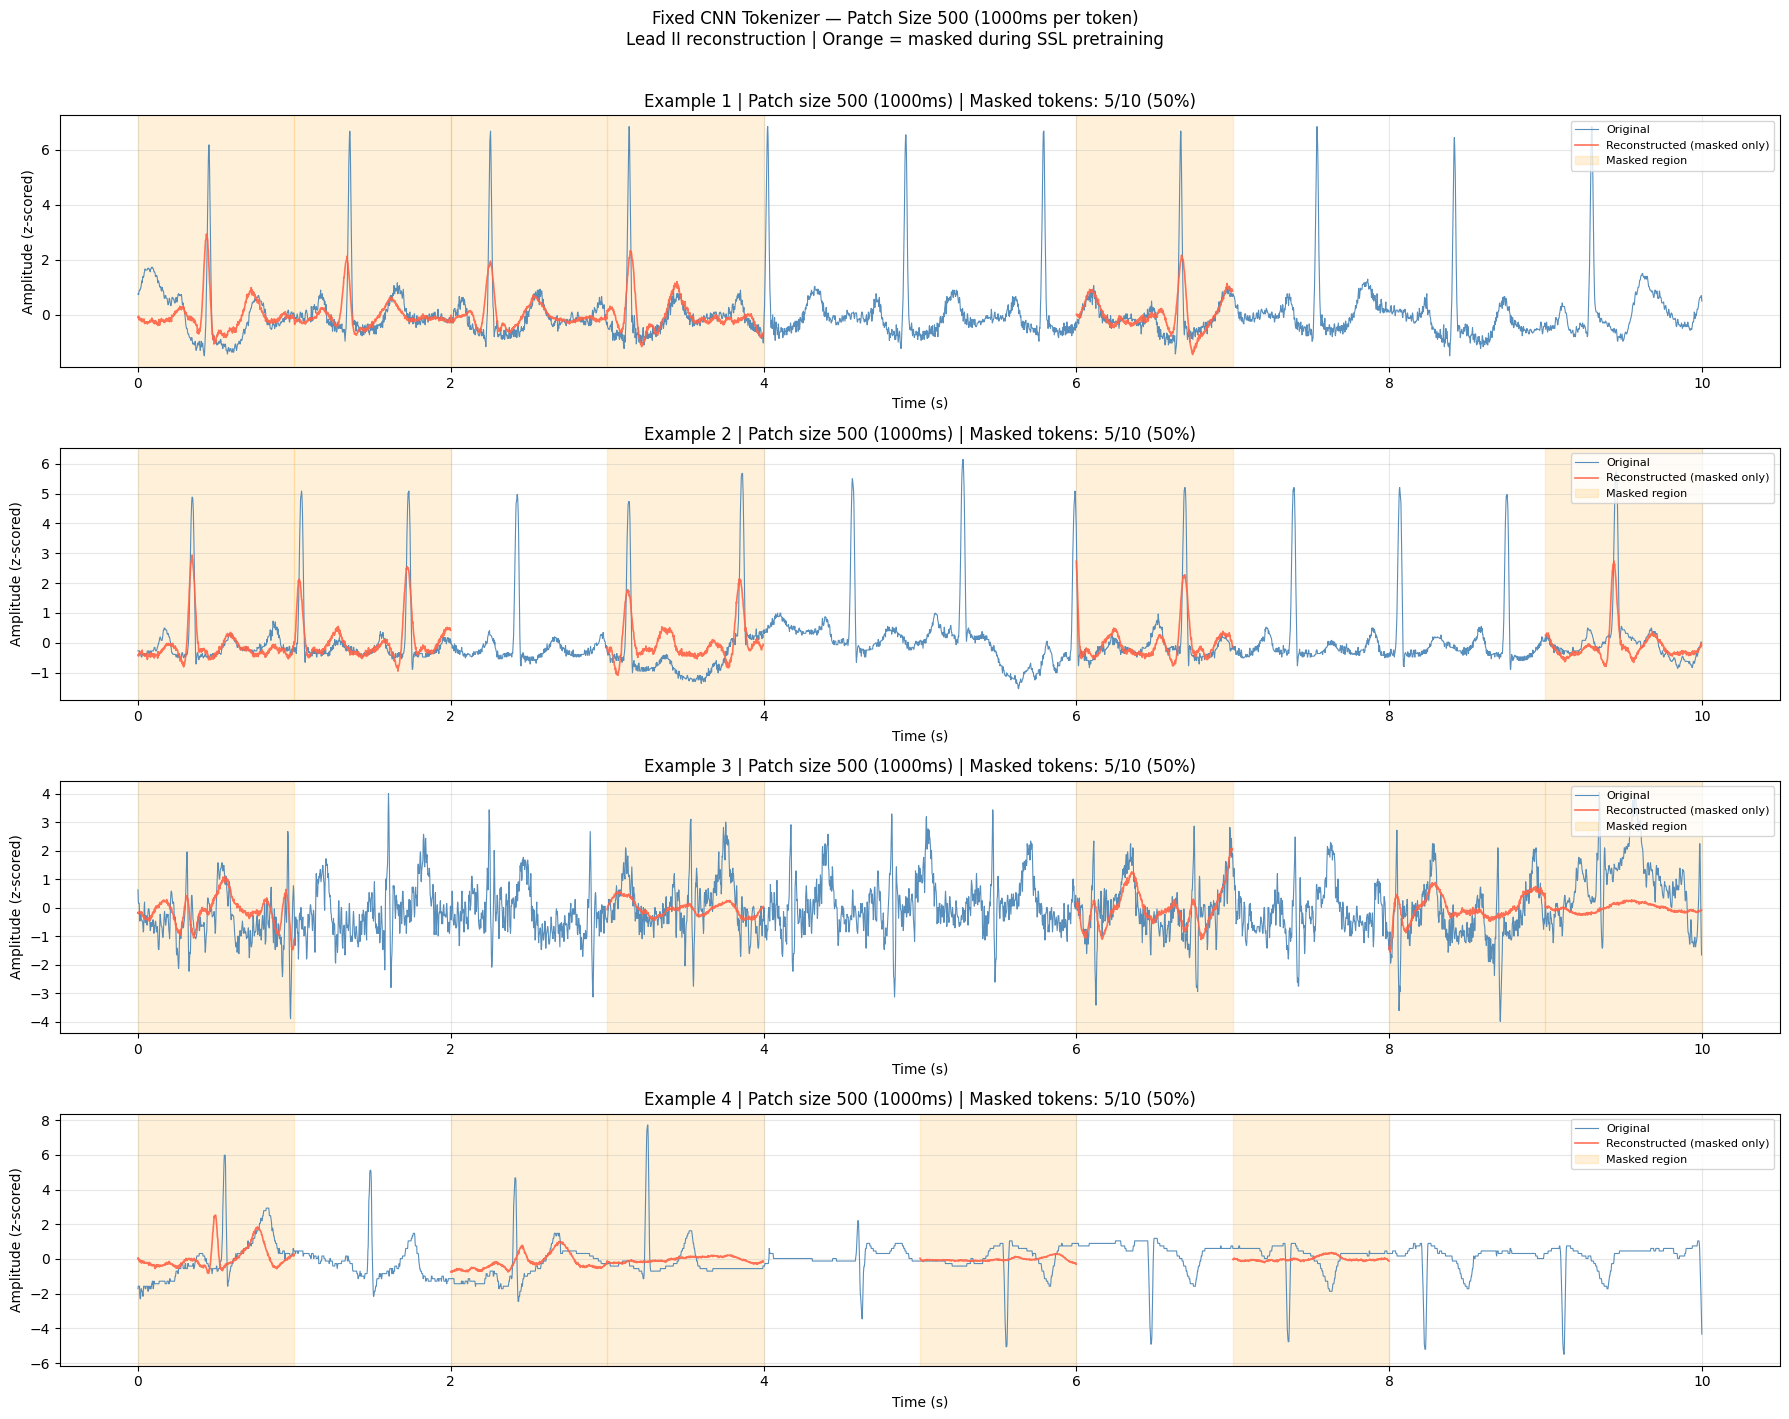

In [5]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import json
import math
from pathlib import Path

# -------------------------
# Pick your patch size here
# -------------------------
PATCH_SIZE_VIZ = 500   # change to 50, 100, 250, or 500

# -------------------------
# Config (must match training)
# -------------------------
SEQ_LEN_VIZ  = 5000 // PATCH_SIZE_VIZ
IN_CHANNELS  = 12
D_MODEL      = 256
NUM_HEADS    = 8
NUM_LAYERS   = 4
MLP_RATIO    = 4
DROPOUT      = 0.1
MASK_RATIO   = 0.50
MASK_SPAN_LEN_VIZ = {50: 5, 100: 3, 250: 1, 500: 1}[PATCH_SIZE_VIZ]

# -------------------------
# Load model
# -------------------------
checkpoint_path = Path(f"checkpoints_fixed{PATCH_SIZE_VIZ}_ssl/best.pt")

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

viz_model = ECGMaskedSSL(
    in_channels=IN_CHANNELS,
    seq_len=SEQ_LEN_VIZ,
    d_model=D_MODEL,
    patch_size=PATCH_SIZE_VIZ,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
).to(device)

state_dict = checkpoint["model_state_dict"]
state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
viz_model.load_state_dict(state_dict)
viz_model.eval()
print(f"Loaded patch_size={PATCH_SIZE_VIZ} from {checkpoint_path}")
print(f"Best val loss: {checkpoint['history'][-1]['val_loss']:.4f}")

# -------------------------
# Load a few val samples from the precomputed cache
# -------------------------
cache_dir      = Path("/data/ahmed/MIMIC_Dataset/mimic_precomputed_npys")
manifest_path  = cache_dir / "manifest.jsonl"
rows           = [json.loads(line) for line in manifest_path.read_text().splitlines()]

# pick 4 random records from the val portion (last 5%)
n_total   = len(rows)
n_train   = int(0.95 * n_total)
val_rows  = rows[n_train:]
chosen    = np.random.choice(len(val_rows), size=4, replace=False)

samples = []
for idx in chosen:
    x = np.load(val_rows[idx]["npy_path"], mmap_mode=None)   # (12, 5000)
    samples.append(torch.from_numpy(x))

x_batch = torch.stack(samples).to(device)   # (4, 12, 5000)

# -------------------------
# Run model
# -------------------------
mask = contiguous_token_mask(
    x_batch.shape[0], SEQ_LEN_VIZ, MASK_RATIO, device, span_len=MASK_SPAN_LEN_VIZ
)

with torch.no_grad():
    out = viz_model(x_batch, mask=mask)

pred    = out["pred_patches"].float().cpu().numpy()    # (4, N, patch_dim)
target  = out["target_patches"].float().cpu().numpy()  # (4, N, patch_dim)
mask_np = out["mask"].cpu().numpy()                    # (4, N)

N = SEQ_LEN_VIZ

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(4, 1, figsize=(18, 3.5 * 4))

for i in range(4):
    ax = axes[i]

    tgt_reshaped  = target[i].reshape(N, 12, PATCH_SIZE_VIZ)   # (N, 12, P)
    pred_reshaped = pred[i].reshape(N, 12, PATCH_SIZE_VIZ)     # (N, 12, P)

    original_signal      = tgt_reshaped[:, 1, :].flatten()    # Lead II, (5000,)

    t = np.arange(5000) / 500.0   # seconds

    reconstructed_display = np.full(5000, np.nan)
    for tok_idx in range(N):
        if mask_np[i, tok_idx]:
            start = tok_idx * PATCH_SIZE_VIZ
            end   = (tok_idx + 1) * PATCH_SIZE_VIZ
            reconstructed_display[start:end] = pred_reshaped[tok_idx, 1, :]

    ax.plot(t, original_signal,       color='steelblue', linewidth=0.8, label='Original',                  alpha=0.9)
    ax.plot(t, reconstructed_display, color='tomato',    linewidth=1.2, label='Reconstructed (masked only)', alpha=0.9)

    first_masked = True
    for tok_idx in range(N):
        if mask_np[i, tok_idx]:
            start_t = tok_idx * PATCH_SIZE_VIZ / 500.0
            end_t   = (tok_idx + 1) * PATCH_SIZE_VIZ / 500.0
            ax.axvspan(start_t, end_t, alpha=0.15, color='orange',
                       label='Masked region' if first_masked else '')
            first_masked = False

    ax.set_title(f"Example {i+1} | Patch size {PATCH_SIZE_VIZ} ({PATCH_SIZE_VIZ*2}ms) | "
                 f"Masked tokens: {mask_np[i].sum()}/{N} ({MASK_RATIO*100:.0f}%)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (z-scored)")
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Fixed CNN Tokenizer — Patch Size {PATCH_SIZE_VIZ} ({PATCH_SIZE_VIZ*2}ms per token)\n"
             f"Lead II reconstruction | Orange = masked during SSL pretraining",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()